# **Fuzzy Logic–Based Mental Health Support Triage System**

This project implements a **Fuzzy Logic–Based Mental Health Support Triage System**, designed to simulate how intelligent systems can assist in evaluating mental health support needs using approximate reasoning rather than rigid thresholds.

Unlike traditional binary decision systems, fuzzy logic allows the system to handle **gradual transitions and uncertainty**, which better reflects real-world psychological assessment. Instead of classifying a person as strictly "low" or "high" risk, the system evaluates **degrees of membership across multiple clinical indicators**.

## Important Safety Note

**This system is strictly for educational and demonstration purposes only.**

This system:

- Does **NOT diagnose depression**
- Does **NOT replace clinical judgment**
- Does **NOT provide medical advice**
- Must **NOT be used to make treatment decisions**

Real-world mental health assessment requires:

- Licensed mental health professionals  
- Clinical interviews and validated diagnostic protocols  
- Privacy and confidentiality safeguards  
- Immediate escalation and intervention pathways when safety risks are present  

This project is only intended to demonstrate how fuzzy logic can be used in intelligent systems.

---

## Immediate Safety Guidance

If someone may be at risk of harm — including:

- Talking about suicide  
- Expressing intent to self-harm  
- Feeling unable to stay safe  

**Immediate action is required.**

Please contact:

- A trusted adult  
- A school counselor  
- A licensed mental health professional  
- Local emergency services  
- A crisis hotline  

If you are in the Philippines and need urgent help, you may contact:

**National Center for Mental Health (NCMH) Crisis Hotline**

If you need help locating the most current official crisis hotline numbers, please consult local health authorities or official government resources.

In [1]:
# Install libraries
!pip install scikit-fuzzy

In [2]:
# Import libraries
import numpy as np
import skfuzzy as fuzz
import skfuzzy.control as ctrl
import matplotlib.pyplot as plt

In [3]:
# Define Universes of Discourse

# Symptom Severity (PHQ-9: 0–27)
symptom_severity = ctrl.Antecedent(np.arange(0, 28, 1), 'Symptom Severity')

symptom_severity['Low'] = fuzz.trimf(symptom_severity.universe, [0, 4.5, 9])
symptom_severity['Moderate'] = fuzz.trimf(symptom_severity.universe, [7, 12, 17])
symptom_severity['High'] = fuzz.trimf(symptom_severity.universe, [15, 22, 27])

# Functional Impairment (0–10)
functional_impairment = ctrl.Antecedent(np.arange(0, 11, 1), 'Functional Impairment')

functional_impairment['Mild'] = fuzz.trimf(functional_impairment.universe, [0, 1.5, 3])
functional_impairment['Moderate'] = fuzz.trimf(functional_impairment.universe, [2, 4.5, 7])
functional_impairment['Severe'] = fuzz.trimf(functional_impairment.universe, [6, 8, 10])

# Suicidal Risk (0–10)
suicidal_risk = ctrl.Antecedent(np.arange(0, 11, 1), 'Suicidal Risk')

suicidal_risk['None'] = fuzz.trimf(suicidal_risk.universe, [0, 0.5, 1])
suicidal_risk['Some'] = fuzz.trimf(suicidal_risk.universe, [1, 3.5, 6])
suicidal_risk['High'] = fuzz.trimf(suicidal_risk.universe, [5, 7.5, 10])

# Symptom Duration (weeks: 0–12)
symptom_duration = ctrl.Antecedent(np.arange(0, 13, 1), 'Symptom Duration')

symptom_duration['Short'] = fuzz.trimf(symptom_duration.universe, [0, 1, 2])
symptom_duration['Medium'] = fuzz.trimf(symptom_duration.universe, [2, 4, 6])
symptom_duration['Long'] = fuzz.trimf(symptom_duration.universe, [6, 9, 12])

# Social Support (0–10) — logical interpretation
# Strong = low risk, Weak = high risk
social_support = ctrl.Antecedent(np.arange(0, 11, 1), 'Social Support')

social_support['Weak'] = fuzz.trimf(social_support.universe, [0, 2.5, 5])
social_support['Moderate'] = fuzz.trimf(social_support.universe, [3, 5, 7])
social_support['Strong'] = fuzz.trimf(social_support.universe, [6, 8.5, 10])

# Stress Load (0–10)
stress_load = ctrl.Antecedent(np.arange(0, 11, 1), 'Stress Load')

stress_load['Low'] = fuzz.trimf(stress_load.universe, [0, 2.5, 5])
stress_load['Moderate'] = fuzz.trimf(stress_load.universe, [3, 5, 7])
stress_load['High'] = fuzz.trimf(stress_load.universe, [6, 8.5, 10])

# Action Level Output (0–100)
# Use trapezoidal on edges and triangular in middle
action_level = ctrl.Consequent(np.arange(0, 101, 1), 'Action Level')

# Monitor & Self-care: 0–30
action_level['Monitor & Self-care'] = fuzz.trapmf(
    action_level.universe, [0, 0, 15, 30]
)

# Schedule Counseling: 20–55
action_level['Schedule Counseling'] = fuzz.trimf(
    action_level.universe, [20, 37.5, 55]
)

# Urgent Referral: 45–80
action_level['Urgent Referral'] = fuzz.trimf(
    action_level.universe, [45, 62.5, 80]
)

# Emergency Protocol: 75–100
action_level['Emergency Protocol'] = fuzz.trapmf(
    action_level.universe, [75, 90, 100, 100]
)

In [4]:
# Create fuzzy rules
rules = [
    # Safety-first override rules
    ctrl.Rule(suicidal_risk['High'], action_level['Emergency Protocol']),
    ctrl.Rule(suicidal_risk['Some'] & functional_impairment['Severe'], action_level['Emergency Protocol']),
    ctrl.Rule(suicidal_risk['Some'] & symptom_severity['High'], action_level['Urgent Referral']),

    # High impairment + high symptoms
    ctrl.Rule(symptom_severity['High'] & functional_impairment['Severe'], action_level['Urgent Referral']),
    ctrl.Rule(symptom_severity['High'] & symptom_duration['Long'], action_level['Urgent Referral']),
    ctrl.Rule(functional_impairment['Severe'] & symptom_duration['Long'], action_level['Urgent Referral']),

    # Moderate cases (typical counseling pathway)
    ctrl.Rule(symptom_severity['Moderate'] & functional_impairment['Moderate'], action_level['Schedule Counseling']),
    ctrl.Rule(symptom_severity['Moderate'] & symptom_duration['Medium'], action_level['Schedule Counseling']),
    ctrl.Rule(functional_impairment['Moderate'] & symptom_duration['Long'], action_level['Schedule Counseling']),

    # Lower-intensity / early support
    ctrl.Rule(symptom_severity['Low'] & functional_impairment['Mild'], action_level['Monitor & Self-care']),
    ctrl.Rule(symptom_severity['Low'] & symptom_duration['Short'], action_level['Monitor & Self-care']),

    # Optional protective/risk modifiers (if you include Social Support / Stress)
    ctrl.Rule(social_support['Weak'] & stress_load['High'], action_level['Schedule Counseling']),
    ctrl.Rule(social_support['Weak'] & symptom_severity['High'], action_level['Urgent Referral']),
    ctrl.Rule(social_support['Strong'] & symptom_severity['Moderate'] & functional_impairment['Mild'], action_level['Monitor & Self-care']),

    # New Rule: If suicidal risk is 'Some' AND symptom severity is 'Moderate' AND functional impairment is 'Moderate', then action level is 'Urgent'
    ctrl.Rule(suicidal_risk['Some'] & symptom_severity['Moderate'] & functional_impairment['Moderate'], action_level['Urgent Referral'],),

    # New Rule: If symptom duration is 'Medium' AND symptom severity is 'Moderate' and functional impairment is 'Moderate', then action level is Urgent'
    ctrl.Rule(symptom_duration['Medium'] & symptom_severity['Moderate'] & functional_impairment['Moderate'], action_level['Urgent Referral']),
]

In [5]:
# Build the Control System
triage_ctrl = ctrl.ControlSystem(rules)

# Create a ControlSystemSimulation object
triage_sim = ctrl.ControlSystemSimulation(triage_ctrl)

In [6]:
# Function: Run the fuzzy triage simulation for given inputs
def run_triage_simulation(
    symptom_severity_val,
    functional_impairment_val,
    suicidal_risk_val,
    symptom_duration_val,
    social_support_val,
    stress_load_val,
):
    # Pass inputs to the ControlSystemSimulation
    triage_sim.input['Symptom Severity'] = symptom_severity_val
    triage_sim.input['Functional Impairment'] = functional_impairment_val
    triage_sim.input['Suicidal Risk'] = suicidal_risk_val
    triage_sim.input['Symptom Duration'] = symptom_duration_val
    triage_sim.input['Social Support'] = social_support_val
    triage_sim.input['Stress Load'] = stress_load_val

    # Compute the result
    triage_sim.compute()

    # Get the defuzzified output
    crisp_output = triage_sim.output['Action Level']

    # Interpret Result
    if crisp_output < 25:
        decision = "Monitor & Self-Care"
    elif crisp_output < 50:
        decision = "Schedule Counseling"
    elif crisp_output < 75:
        decision = "Urgent Referral"
    else:
        decision = "Emergency Protocol"

    action_level.view(sim=triage_sim)

    return crisp_output, decision

--- Test Case A ---
Crisp Output: 12.67, Recommended Action: Monitor & Self-Care



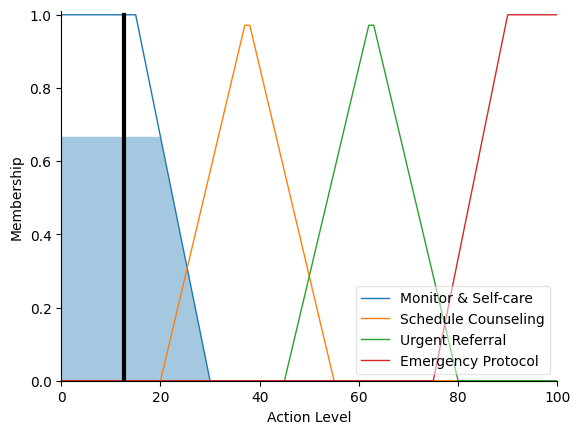

In [7]:
# Case A: PHQ-9=6 (Low), Impairment=2 (Mild), SuicideRisk=0 (None), Duration=1 week (Short)
# → Monitor & self-care (low output)
print("--- Test Case A ---")
crisp_output_a, decision_a = run_triage_simulation(6, 2, 0, 1, 5, 5)
print(f"Crisp Output: {crisp_output_a:.2f}, Recommended Action: {decision_a}\n")

--- Test Case B ---
Crisp Output: 49.25, Recommended Action: Schedule Counseling



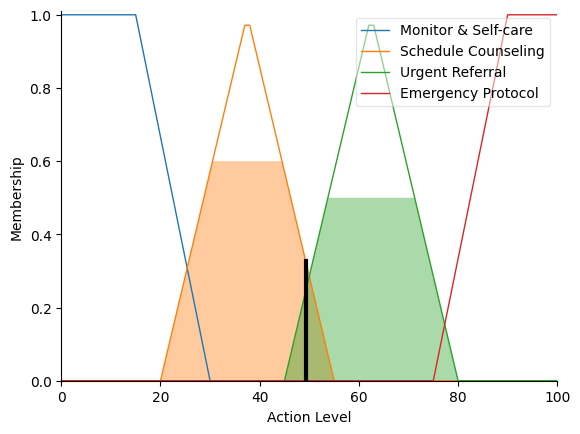

In [8]:
# Case B: PHQ-9=14 (Moderate), Impairment=5 (Moderate), SuicideRisk=1 (Some), Duration=5 weeks (Medium)
# → Counseling to Urgent (mid-high output)
print("--- Test Case B ---")
crisp_output_b, decision_b = run_triage_simulation(14, 5, 1, 5, 5, 5)
print(f"Crisp Output: {crisp_output_b:.2f}, Recommended Action: {decision_b}\n")

--- Test Case C ---
Crisp Output: 71.77, Recommended Action: Urgent Referral



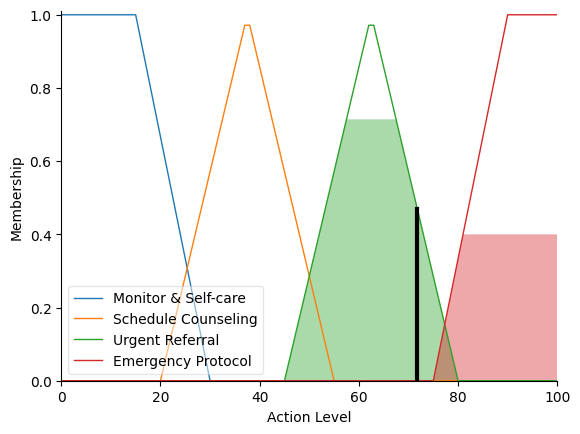

In [9]:
# Case C: PHQ-9=20 (High), Impairment=8 (Severe), SuicideRisk=2 (Some), Duration=10 weeks (Long)
# → Urgent referral (high output)
print("--- Test Case C ---")
crisp_output_c, decision_c = run_triage_simulation(20, 8, 2, 10, 5, 5)
print(f"Crisp Output: {crisp_output_c:.2f}, Recommended Action: {decision_c}\n")

--- Test Case D ---
Crisp Output: 90.18, Recommended Action: Emergency Protocol


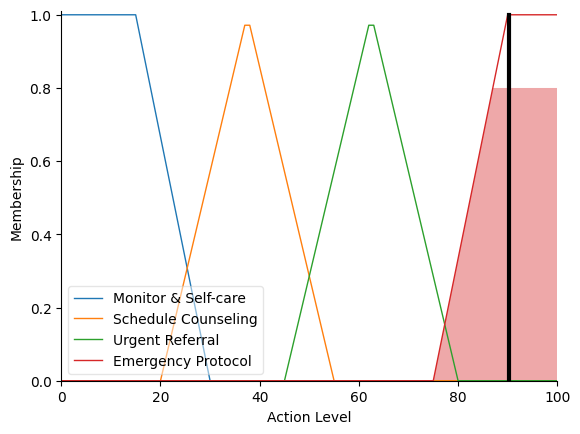

In [10]:
# Case D: SuicideRisk=8 (High) regardless of other inputs
# → Emergency (very high output)
print("--- Test Case D ---")
crisp_output_d, decision_d = run_triage_simulation(0, 0, 8, 0, 10, 0)
print(f"Crisp Output: {crisp_output_d:.2f}, Recommended Action: {decision_d}")

### **REFLECTION**
- This activity highlighted how fuzzy logic captures the nuanced, threshold-free reasoning that guidance counselors and mental health professionals use in practice.
- Unlike Boolean logic, where a student either has severe symptoms or does not, fuzzy sets allow partial membership so that a PHQ-9 score of 14, for example, can belong simultaneously to Moderate and High categories. This overlapping membership closely mirrors clinical judgment, where boundaries between categories are rarely sharp.
- Working with Test Case B revealed the importance of carefully designed rules as initially, the system recommended only Schedule Counseling even though the combination of moderate symptoms, moderate functional impairment, some suicidal risk, and medium symptom duration should have prompted a more urgent response.
- Adding parallel rules that activated both Schedule Counseling and Urgent Referral allowed the system to produce a blended output, reflecting a mid-high urgency level.
- This experience taught me how safety-first override rules dominate all other signals when suicidal risk is elevated, ensuring that risk always takes precedence over symptom scores alone.
- The main challenge was managing interactions between rules without altering membership functions.
- Early attempts produced outputs that were either too low or failed to reflect overlapping concern because only one rule dominated.
- Introducing additional rules that shared the same input conditions but targeted different outputs allowed the system to more accurately reflect combined risk.
- I learned that fuzzy logic differs from Boolean logic by accommodating uncertainty and gradation, allowing decision-support systems to emulate professional reasoning when input data are imprecise.
- While fuzzy logic is not a replacement for professional assessment, it can help triage coordinators prioritize which students need attention most urgently, especially when caseloads are high and intake information is limited.